# 03 — Validación sintético vs donor_validation

Compara ventanas generadas con `donor_validation` (permitido). **No usar NVDA visible/test.**

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import CHANNELS, load_donor_windows, windows_to_array
from src.metrics import compare_parquet_splits, save_validation_report
from src.paths import default_windows_dir, outputs_dir

sns.set_theme(style="whitegrid")

I0000 00:00:1788085220.202562  720917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788085220.202918  720917 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788085220.236432  720917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788085221.304956  720917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
# Ajustar al parquet generado
SYNTHETIC_PATH = sorted(outputs_dir().glob("synthetic_*.parquet"))[-1]
print(SYNTHETIC_PATH)

synthetic = pd.read_parquet(SYNTHETIC_PATH)
validation = load_donor_windows("donor_validation", windows_dir=default_windows_dir())

X_syn = windows_to_array(synthetic)
X_val = windows_to_array(validation)
print(X_syn.shape, X_val.shape)

/home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/outputs/synthetic_seed42_ratio0.25.parquet
(50, 65, 3) (380, 65, 3)


In [3]:
report = compare_parquet_splits(validation, synthetic)
print(f"MMD (flat): {report.mmd_flat:.6f}")
display(report.channel_summary_real)
display(report.channel_summary_synthetic)
display(report.autocorr_real)
display(report.autocorr_synthetic)

save_validation_report(report, SYNTHETIC_PATH.with_suffix(".validation.json"))

MMD (flat): 0.025600


,channel,mean,std,min,max
0,log_return,-0.001630,0.029279,-0.149299,0.149978
1,log_high_low_range,0.036210,0.015943,0.009586,0.128724
2,log1p_volume,16.219625,1.115950,13.508171,19.233361


,channel,mean,std,min,max
0,log_return,0.000810,0.021097,-0.076646,0.080532
1,log_high_low_range,0.026418,0.015061,-0.025103,0.090346
2,log1p_volume,16.094977,1.330002,11.887916,20.268793


,channel,autocorr_lag1_mean,autocorr_lag1_std
0,log_return,-0.058412,0.099225
1,log_high_low_range,0.072556,0.096640
2,log1p_volume,0.362559,0.152487


,channel,autocorr_lag1_mean,autocorr_lag1_std
0,log_return,-0.037634,0.108101
1,log_high_low_range,0.256948,0.160915
2,log1p_volume,0.252352,0.157482


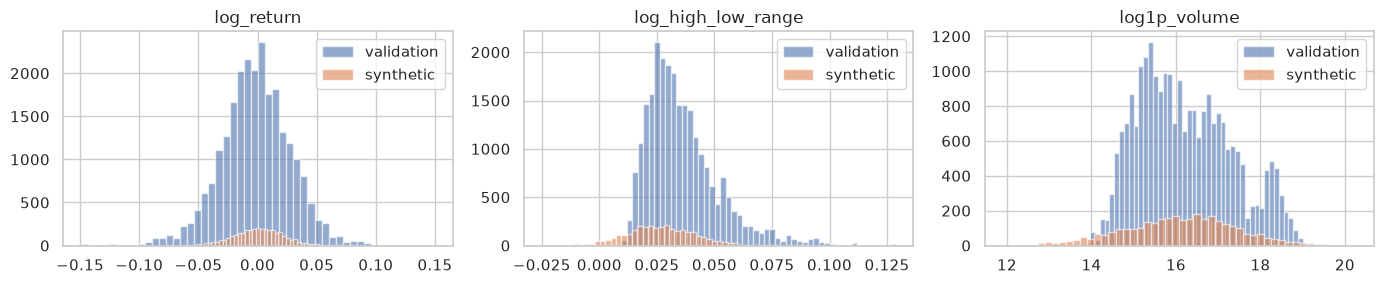

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, idx, name in zip(axes, range(3), CHANNELS):
    ax.hist(X_val[:, :, idx].reshape(-1), bins=50, alpha=0.6, label="validation")
    ax.hist(X_syn[:, :, idx].reshape(-1), bins=50, alpha=0.6, label="synthetic")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()

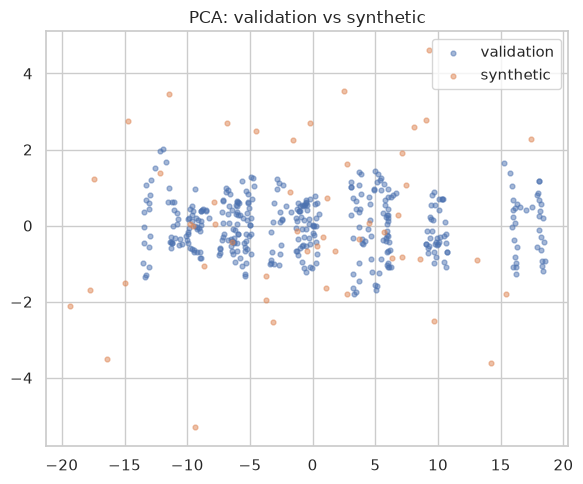

In [5]:
from sklearn.decomposition import PCA

flat_val = X_val.reshape(len(X_val), -1)
flat_syn = X_syn.reshape(len(X_syn), -1)
combined = np.vstack([flat_val, flat_syn])
labels = np.array(["validation"] * len(flat_val) + ["synthetic"] * len(flat_syn))

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined)

plt.figure(figsize=(6, 5))
for label, color in [("validation", "C0"), ("synthetic", "C1")]:
    mask = labels == label
    plt.scatter(coords[mask, 0], coords[mask, 1], s=12, alpha=0.5, label=label, c=color)
plt.legend()
plt.title("PCA: validation vs synthetic")
plt.tight_layout()

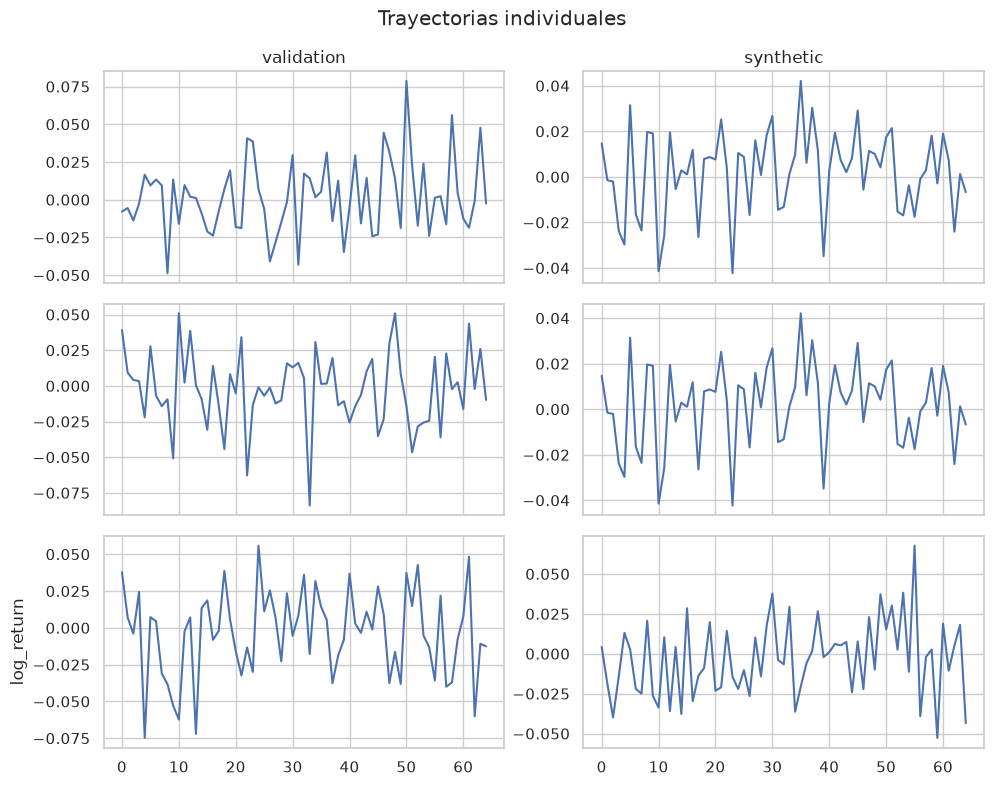

In [6]:
rng = np.random.default_rng(42)
idx_val = rng.choice(len(X_val), 3)
idx_syn = rng.choice(len(X_syn), 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for row in range(3):
    axes[row, 0].plot(X_val[idx_val[row], :, 0])
    axes[row, 1].plot(X_syn[idx_syn[row], :, 0])
    if row == 0:
        axes[row, 0].set_title("validation")
        axes[row, 1].set_title("synthetic")
axes[row, 0].set_ylabel("log_return")
plt.suptitle("Trayectorias individuales")
plt.tight_layout()